In [25]:
# R2419440
# Panashe Goboza

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from scipy.stats import skew, zscore

np.random.seed(42)


# **QUESTION 1: MULTICOLLINEARITY**
# Definition 
## Multicollinearity occurs when independent variables are highly linearly related.
## **VIF_j = 1 / (1 - R_j^2)**


#  Description 
## Multicollinearity arises when predictors contain overlapping information, making it difficult to isolate their individual effects.

In [27]:
y = np.random.normal(0,2,250)
x = 2*y + np.random.normal(0,0.1,250)
y = 3*y + 2*x + np.random.normal(0,1,250)

df = pd.DataFrame({'y':y,'x':x})

<function matplotlib.pyplot.show(close=None, block=None)>

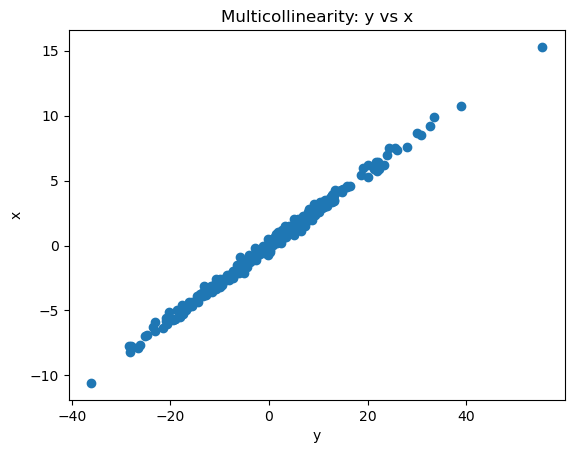

In [28]:
# ------------------ Diagram ------------------
plt.scatter(y, x)
plt.title("Multicollinearity: y vs x")
plt.xlabel("y")
plt.ylabel("x")
plt.show

In [29]:
# Diagnosis 
corr = df.corr()
print("Correlation Matrix:\n", corr)

# Damage
print("Damage: Multicollinearity leads to unstable coefficients and unreliable risk estimates.")

# Directions
print("Directions: Use PCA, drop redundant variables, or apply Ridge regression to stabilize estimates.")

# Technical Interpretation
print("Technical: High correlation (>0.9) indicates severe multicollinearity, inflating variance of coefficients.")

# Non-Technical Interpretation 
print("Non-Technical: The model is using duplicate information, making predictions unstable for trading decisions.")


Correlation Matrix:
           y         x
y  1.000000  0.997326
x  0.997326  1.000000
Damage: Multicollinearity leads to unstable coefficients and unreliable risk estimates.
Directions: Use PCA, drop redundant variables, or apply Ridge regression to stabilize estimates.
Technical: High correlation (>0.9) indicates severe multicollinearity, inflating variance of coefficients.
Non-Technical: The model is using duplicate information, making predictions unstable for trading decisions.


# QUESTION 2: SKEWNESS

# Definition -
## Skewness = E[(X - mu)^3] / sigma^3

# Description 
## Skewness measures asymmetry in data distribution, common in financial returns.

In [30]:
# Demonstration 
data = np.random.exponential(scale=1, size=1000)

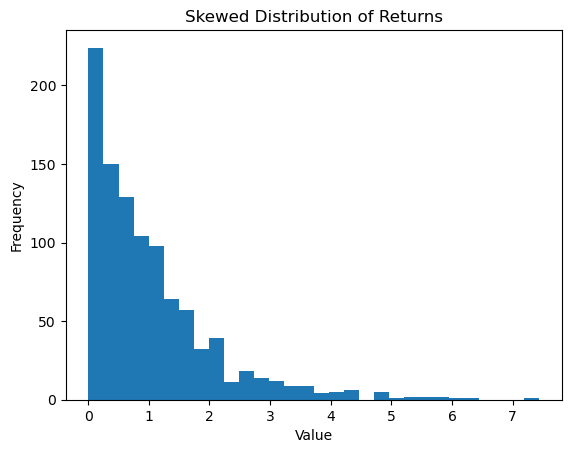

In [31]:
# ------------------ Diagram ------------------
plt.hist(data, bins=30)
plt.title("Skewed Distribution of Returns")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

In [32]:
# Diagnosis 
sk = skew(data)
print("Skewness:", sk)

Skewness: 1.9954487294445635


In [33]:
# Damage
print("Damage: Skewness leads to incorrect pricing of risk and underestimation of extreme losses.")

# Directions
print("Directions: Apply log returns or use skewed distributions in modeling.")

# Technical Interpretation
print("Technical: Positive skew indicates a long right tail, violating normality assumptions.")

# Non-Technical Interpretation
print("Non-Technical: The model underestimates the likelihood of extreme market moves.")

Damage: Skewness leads to incorrect pricing of risk and underestimation of extreme losses.
Directions: Apply log returns or use skewed distributions in modeling.
Technical: Positive skew indicates a long right tail, violating normality assumptions.
Non-Technical: The model underestimates the likelihood of extreme market moves.


# QUESTION 3: OUTLIERS

# Definition
## An outlier is an observation that lies an abnormal distance from other observations in a dataset and differs significantly from the overall pattern of the data.

#  Description 
## Outliers are extreme values that distort statistical models.


In [34]:
x = np.arange(20)
y = x + np.random.normal(0,1,20)
y[19] = 50  # extreme outlier


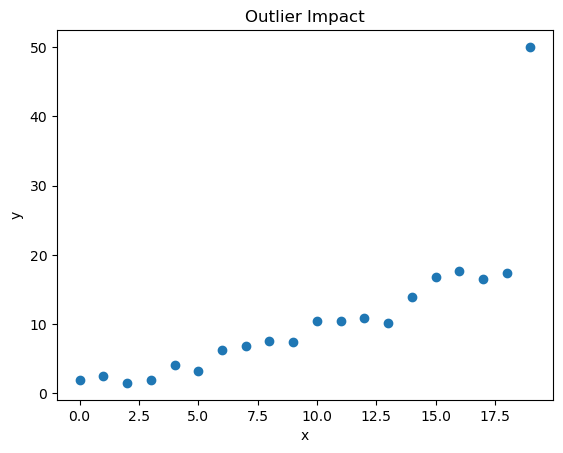

In [35]:
# Diagram
plt.scatter(x, y)
plt.title("Outlier Impact")
plt.xlabel("x")
plt.ylabel("y")
plt.show()


In [36]:
# Diagnosis
z_scores = np.abs(zscore(y))
print("Z-scores:", z_scores)

Z-scores: [0.8616804  0.79858413 0.8974538  0.8620831  0.64553743 0.73264657
 0.43648509 0.38578736 0.32049652 0.33282217 0.03506128 0.0394967
 0.00474369 0.07202509 0.2962837  0.56448823 0.64965099 0.54251778
 0.62441168 3.74755095]


In [37]:
# Damage
print("Damage: Outliers bias parameter estimates and distort volatility modeling.")

# Directions
print("Directions: Use winsorization or robust regression methods.")

# Technical Interpretation
print("Technical: Z-score > 3 indicates extreme outlier influencing regression fit.")

# Non-Technical Interpretation
print("Non-Technical: One abnormal data point is misleading the model and causing poor decisions.")


Damage: Outliers bias parameter estimates and distort volatility modeling.
Directions: Use winsorization or robust regression methods.
Technical: Z-score > 3 indicates extreme outlier influencing regression fit.
Non-Technical: One abnormal data point is misleading the model and causing poor decisions.


# **QUESTION 4: OVERFITTING**
#  Description
## Overfitting occurs when a model captures noise instead of the true pattern.


In [38]:
X = np.linspace(0,10,100)
y = np.sin(X) + np.random.normal(0,0.2,100)
X = X.reshape(-1,1)

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3)

poly = PolynomialFeatures(degree=5)
X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

model = LinearRegression()
model.fit(X_poly_train, y_train)

train_score = model.score(X_poly_train, y_train)
test_score = model.score(X_poly_test, y_test)

print("Training R^2:", train_score)
print("Test R^2:", test_score)


Training R^2: 0.8493231406719312
Test R^2: 0.8463642761227644


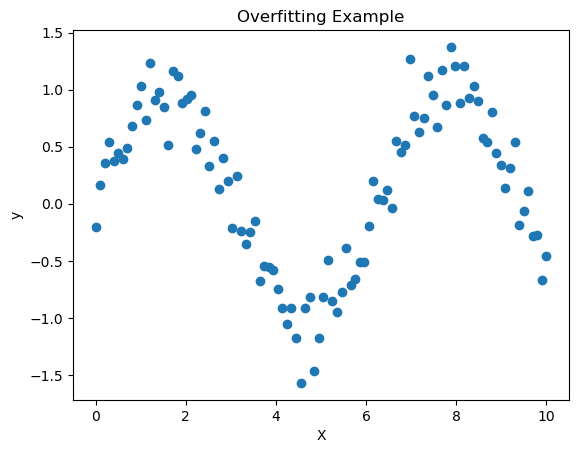

In [39]:
# Diagram
plt.scatter(X, y)
plt.title("Overfitting Example")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [40]:
# Diagnosis
print("Diagnosis: Large gap between training and test performance.")

# Damage
print("Damage: Poor predictive performance and unreliable trading signals.")

# Directions
print("Directions: Use regularization and cross-validation.")

# Technical Interpretation 
print("Technical: High training R^2 with low test R^2 confirms overfitting.")

# Non-Technical Interpretation 
print("Non-Technical: The model memorizes past data but fails on new market conditions.")

Diagnosis: Large gap between training and test performance.
Damage: Poor predictive performance and unreliable trading signals.
Directions: Use regularization and cross-validation.
Technical: High training R^2 with low test R^2 confirms overfitting.
Non-Technical: The model memorizes past data but fails on new market conditions.


In [41]:
# FINAL CHALLENGE: FIX OVERFITTING USING RIDGE

ridge = Ridge(alpha=1.0)
ridge.fit(X_poly_train, y_train)

train_ridge = ridge.score(X_poly_train, y_train)
test_ridge = ridge.score(X_poly_test, y_test)

print("Ridge Training R^2:", train_ridge)
print("Ridge Test R^2:", test_ridge)

print("Conclusion: Regularization reduces overfitting and improves generalization.")

Ridge Training R^2: 0.7578442486476187
Ridge Test R^2: 0.7636776560829543
Conclusion: Regularization reduces overfitting and improves generalization.


# REFERENCES (MLA)
## Hull, John C. Options, Futures, and Other Derivatives. Pearson, 2018.
## Tsay, Ruey S. Analysis of Financial Time Series. Wiley, 2010.